# **Week 1 Assignment — ML Foundations**

---



In [ ]:
#importing required modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from io import StringIO

plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print('All imports OK ✓')

All imports OK ✓


## **Part 1 - Python fundamentals**

### 1.1 Data Typeas & Control Flow

In [ ]:
def classify_number(n):
  if n<0:
    return "negative"
  elif n==0:
    return "zero"
  elif 0<n<=10:
    return "small positive"
  else:
    return "large positive"

#Tests
assert classify_number(-5)=="negative"
assert classify_number(0)=="zero"
assert classify_number(7)=="small positive"
assert classify_number(42)=="large positive"
print("1.1 passed ✓")

1.1 passed ✓


### 1.2 Data Structures

In [ ]:
words = ['apple', 'banana', 'cherry', 'apple', 'date', 'banana', 'apple']

# 1. word_count dict
word_count = {}
for word in words:
  word_count[word]=word_count.get(word,0)+1

# 2. unique_words set
unique_words = set(words) # Using a set, to find all unique words

# 3. long_words list comprehension
long_words = [word for word in words if len(word)>5] #Using a list comprehension, to filter words with more than 5 characters

# Tests
assert word_count == {'apple': 3, 'banana': 2, 'cherry': 1, 'date': 1}
assert unique_words == {'apple', 'banana', 'cherry', 'date'}
assert set(long_words) == {'banana', 'cherry'}
print("1.2 passed ✓")

1.2 passed ✓


### 1.3 Exceptions

In [ ]:
def safe_divide(a, b):
    if not(isinstance(a,(int,float)) and isinstance(b,(int,float))):
      raise TypeError("Inputs must be numeric")
    try:
      return a/b
    except ZeroDivisionError:
      return None

# Tests
assert safe_divide(10, 2) == 5.0
assert safe_divide(5, 0) is None
try:
    safe_divide('x', 2)
    assert False, "Should have raised TypeError"
except TypeError as e:
    assert str(e) == "Inputs must be numeric"
print("1.3 passed ✓")

1.3 passed ✓


### 1.4 Functions & Lambdas

In [ ]:
def apply_twice(f, x):
    return f(f(x))

triple =lambda x:x*3

result = apply_twice(triple, 4)
assert result == 36, f"Expected 36, got {result}"
print("1.4 passed ✓")

1.4 passed ✓



---

## **Part 2 - NumPy**

### 2.1 Array Creation & Shapes

In [ ]:
arr1d = np.arange(12)
arr2d = arr1d.reshape(3,4)
arr3d = arr1d.reshape(2,2,3)

# Tests
assert arr1d.shape == (12,)
assert arr2d.shape == (3, 4)
assert arr3d.shape == (2, 2, 3)
print("2.1 passed ✓")
print(f"arr2d:\n{arr2d}")
print(f"arr3d:\n{arr3d}")

2.1 passed ✓
arr2d:
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
arr3d:
[[[ 0  1  2]
  [ 3  4  5]]

 [[ 6  7  8]
  [ 9 10 11]]]


### 2.2 Indexing & Slicing

In [ ]:
row2 = arr2d[1,:]
col3 = arr2d[:,2]
sub  = arr2d[1:,2:]
gt7  = arr2d[arr2d>7]

# Tests
assert list(row2) == [4, 5, 6, 7]
assert list(col3) == [2, 6, 10]
assert sub.shape == (2, 2)
assert list(gt7) == [8, 9, 10, 11]
print("2.2 passed ✓")

2.2 passed ✓


### 2.3 Operations & Dot Produt

In [ ]:
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

C  = A*B
D  = A@B
dp = np.dot(np.array([1,2,3]),np.array([4,5,6]))
E  = A*3

# Tests
assert np.array_equal(C, [[5,12],[21,32]])
assert np.array_equal(D, [[19,22],[43,50]])
assert dp == 32
assert np.array_equal(E, [[3,6],[9,12]])
print("2.3 passed ✓")

2.3 passed ✓



---

## **Part 3 - Pandas**

In [ ]:
CSV_DATA = """employee_id,name,department,salary,age,years_exp,performance
1,Alice,Engineering,95000,30,5,4.2
2,Bob,Marketing,72000,35,8,3.8
3,Carol,Engineering,88000,28,3,4.5
4,Dave,HR,61000,42,15,3.1
5,Eve,Engineering,102000,38,12,4.8
6,Frank,Marketing,68000,29,4,3.5
7,Grace,HR,,31,6,3.9
8,Hank,Engineering,91000,45,20,4.1
9,Iris,Marketing,75000,,7,4.0
10,Jack,Engineering,85000,33,8,
"""
df = pd.read_csv(StringIO(CSV_DATA))
print(f"Shape: {df.shape}")
df.head()

Shape: (10, 7)


,employee_id,name,department,salary,age,years_exp,performance
0,1,Alice,Engineering,95000.0,30.0,5,4.2
1,2,Bob,Marketing,72000.0,35.0,8,3.8
2,3,Carol,Engineering,88000.0,28.0,3,4.5
3,4,Dave,HR,61000.0,42.0,15,3.1
4,5,Eve,Engineering,102000.0,38.0,12,4.8


### 3.1 DataFrames vs Saries

In [ ]:
salary_series = df['salary']
name_dept_df  = df[['name','department']]

assert isinstance(salary_series, pd.Series)
assert isinstance(name_dept_df, pd.DataFrame)
print(f"salary_series type: {type(salary_series).__name__}")
print(f"name_dept_df type: {type(name_dept_df).__name__}")
print("3.1 passed ✓")

salary_series type: Series
name_dept_df type: DataFrame
3.1 passed ✓


### 3.2 iloc & loc

In [ ]:
iloc_result = df.iloc[2:5,0:3]
loc_result  = df.loc[5:6,['name','salary']]

assert iloc_result.shape == (3, 3)
assert list(loc_result.columns) == ['name', 'salary']
print("3.2 passed ✓")
display(iloc_result)
display(loc_result)

3.2 passed ✓


,employee_id,name,department
2,3,Carol,Engineering
3,4,Dave,HR
4,5,Eve,Engineering


,name,salary
5,Frank,68000.0
6,Grace,NaN


### 3.3 Filtering & Group By

In [ ]:
senior_eng = df[(df['department']=='Engineering') & (df['salary']>90000)]
dept_stats = df.groupby('department')[['salary', 'performance']].mean().sort_values(by='salary',ascending=False)

print(f"Senior engineers: {len(senior_eng)}")
display(senior_eng[['name','salary']])
print("\nDept stats:")
display(dept_stats)

Senior engineers: 3


,name,salary
0,Alice,95000.0
4,Eve,102000.0
7,Hank,91000.0



Dept stats:


,salary,performance
department,,
Engineering,92200.000000,4.400000
Marketing,71666.666667,3.766667
HR,61000.000000,3.500000


### 3.4 Handling Missing Data

In [ ]:
print("Missing values before:")
print(df.isnull().sum())

df_filled = df.copy()
df_filled['salary']=df_filled['salary'].fillna(df_filled['salary'].median())
df_filled['age']=df_filled['age'].fillna(round(df_filled['age'].mean()))
df_filled=df_filled.dropna(subset=['performance'])

print("\nMissing values after:")
print(df_filled.isnull().sum())
assert df_filled.isnull().sum().sum() == 0, "Still has nulls!"
print("3.4 passed ✓")

Missing values before:
employee_id    0
name           0
department     0
salary         1
age            1
years_exp      0
performance    1
dtype: int64

Missing values after:
employee_id    0
name           0
department     0
salary         0
age            0
years_exp      0
performance    0
dtype: int64
3.4 passed ✓


---

## Part 4 - Linear Algebra

### 4.1 Vectors & Matrices as Data

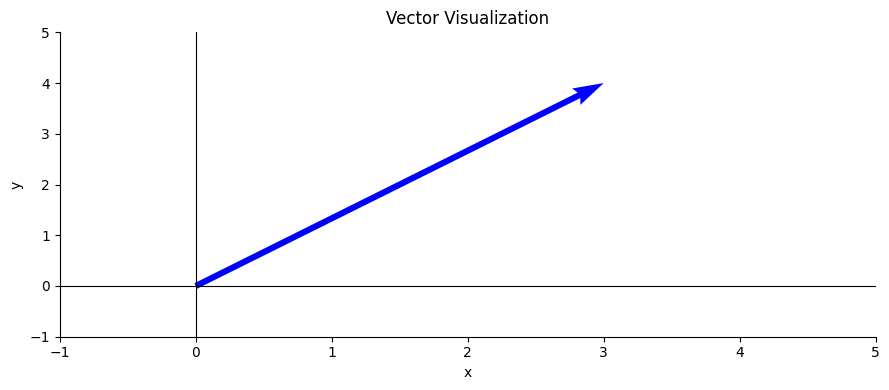

4.1 passed ✓  |v| = 5.0


In [ ]:
v = np.array([3, 4])
norm_v = np.linalg.norm(v)

M = np.array([[1,2,3],[4,5,6],[7,8,9]])

# Plot
fig, ax = plt.subplots()
ax.quiver(0,0,v[0],v[1],angles='xy',scale_units='xy',scale=1,color='b',label='v (3,4)')
ax.set_xlim(-1, 5); ax.set_ylim(-1, 5)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Vector Visualization')
ax.axhline(0, color='k', lw=0.8); ax.axvline(0, color='k', lw=0.8)
plt.tight_layout(); plt.show()

assert abs(norm_v - 5.0) < 1e-9
assert M.shape == (3, 3)
print(f"4.1 passed ✓  |v| = {norm_v}")

### 4.2 Matrix Operations in Practice

In [ ]:
P = np.array([[2, 1], [0, 3]])
Q = np.array([[1, 4], [2, 0]])

PplusQ   = P+Q
scalar3P = 3*P
PQ       = P@Q
QP       = Q@P

print(f"P + Q =\n{PplusQ}")
print(f"3*P =\n{scalar3P}")
print(f"P @ Q =\n{PQ}")
print(f"Q @ P =\n{QP}")
print(f"PQ == QP? {np.array_equal(PQ, QP)}")

assert not np.array_equal(PQ, QP), "They should differ!"
print("4.2 passed ✓")

P + Q =
[[3 5]
 [2 3]]
3*P =
[[6 3]
 [0 9]]
P @ Q =
[[4 8]
 [6 0]]
Q @ P =
[[ 2 13]
 [ 4  2]]
PQ == QP? False
4.2 passed ✓


### 4.3 Eigenvalues & Eigenvectors

Eigenvalues: [5. 2.]
Eigenvectors (columns):
[[ 0.70710678 -0.4472136 ]
 [ 0.70710678  0.89442719]]


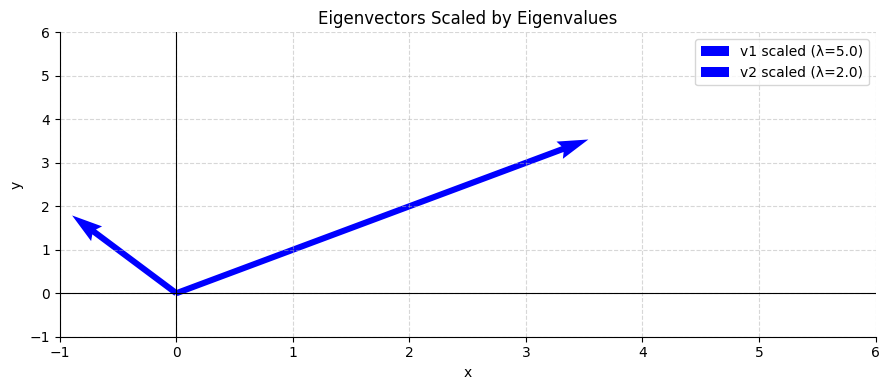

4.3 passed ✓


In [ ]:
A = np.array([[4, 1], [2, 3]], dtype=float)

eigenvalues, eigenvectors = np.linalg.eig(A)

print(f"Eigenvalues: {eigenvalues}")
print(f"Eigenvectors (columns):\n{eigenvectors}")

# Verify Av = λv for each eigenpair
for i in range(len(eigenvalues)):
  lam=eigenvalues[i]
  v_vec=eigenvectors[:, i]
  assert np.allclose(A@v_vec,lam*v_vec), f"Eigenpair {i} failed validation"

# Plot
fig,ax=plt.subplots()
for i in range(len(eigenvalues)):
  lam=eigenvalues[i]
  v_vec=eigenvectors[:, i]*lam
  ax.quiver(0,0,v_vec[0],v_vec[1],angles='xy',scale_units='xy',scale=1,color='b',label=f'v{i+1} scaled (λ={lam})')

ax.set_xlim(-1, 6)
ax.set_ylim(-1, 6)

ax.set_xlabel('x')
ax.set_ylabel('y')

ax.set_title('Eigenvectors Scaled by Eigenvalues')
ax.axhline(0, color='k', lw=0.8); ax.axvline(0, color='k', lw=0.8)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()
print("4.3 passed ✓")

**Geometric Meaning of Matrix Stretching**

Geometrically, when a matrix $A$ multiplies a generic vector, it transforms it by both **rotating** it (changing its direction) and **scaling** it (changing its length).

However, for certain special vectors, the matrix **only stretches, shrinks, or reverses** the vector without changing its fundamental line of direction.

* The **Eigenvector ($\mathbf{X}$)** represents this special spatial direction that remains invariant to rotation under the transformation.
* The **Eigenvalue ($\lambda$)** represents the scale factor of that stretch. If $\lambda = 5$, the matrix stretches the vector to 5 times its original length along that same directional axis.

### 4.4 SVD & Dimensionality Reduction

In [ ]:
np.random.seed(42)
X = np.random.randn(4, 3)

U, S, Vt = np.linalg.svd(X,full_matrices=False)

X_reconstructed = U@np.diag(S)@Vt
X_approx        = U[:,:1]@np.diag(S[:1])@Vt[:1,:]


print(f"U shape: {U.shape}, S shape: {S.shape}, Vt shape: {Vt.shape}")
print(f"Singular values: {S}")
print(f"Reconstruction error: {np.linalg.norm(X - X_reconstructed):.2e}")
print(f"Rank-1 approximation:\n{X_approx}")

assert np.allclose(X, X_reconstructed, atol=1e-10), "Reconstruction failed!"
print("4.4 passed ✓")

U shape: (4, 3), S shape: (3,), Vt shape: (3, 3)
Singular values: [2.37642759 0.91384752 0.81326001]
Reconstruction error: 8.01e-16
Rank-1 approximation:
[[ 0.31621043  0.03811706 -0.07014701]
 [ 1.45405951  0.17527718 -0.32256347]
 [ 1.66945396  0.20124154 -0.37034582]
 [ 0.55465885  0.06686043 -0.12304358]]
4.4 passed ✓


**SVD → PCA Connection (4.4):**

In the decomposition **X = U S Vᵀ**, the rows of **Vᵀ** (columns of **V**) are the *principal directions* — they are the directions of maximum variance in the data, exactly what PCA's eigenvectors represent. The singular values in **S** are proportional to the square root of the variance explained along each direction (they equal the standard deviations of the projected data when X is centred). **U** holds the coordinates of each data point in the new principal-component space. A rank-k approximation keeps only the top-k singular values and vectors, capturing the most variance with the fewest dimensions — this is the core operation of PCA-based dimensionality reduction.

---
## Part 5 - Statistics

### 5.1 Descriptive vs Inferential Statistics

Mean:   81889
Median: 85000
Std:    13606
Range:  61000 – 102000
IQR:    19000


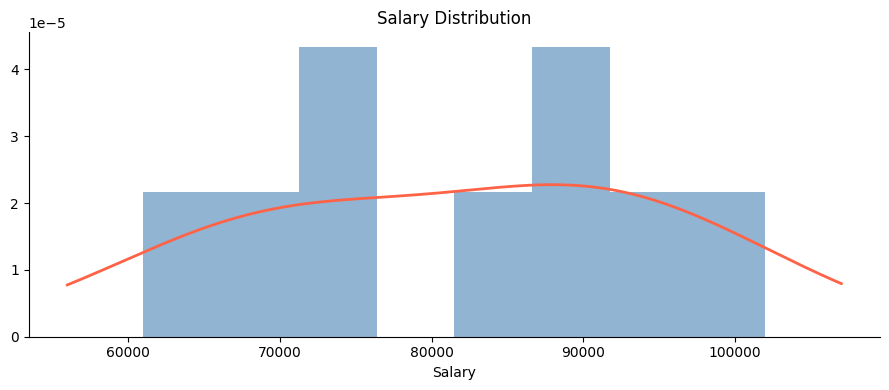

In [ ]:
salary = df_filled['salary']

mean_s   = salary.mean()
median_s = salary.median()
std_s    = salary.std()
min_s    = salary.min()
max_s    = salary.max()
iqr_s    = np.percentile(salary,75)-np.percentile(salary,25)

print(f"Mean:   {mean_s:.0f}")
print(f"Median: {median_s:.0f}")
print(f"Std:    {std_s:.0f}")
print(f"Range:  {min_s:.0f} – {max_s:.0f}")
print(f"IQR:    {iqr_s:.0f}")

# Histogram + KDE
fig, ax = plt.subplots()

ax.hist(salary, bins=8, density=True, alpha=0.6, color='steelblue', label='Histogram')
kde_x = np.linspace(salary.min() - 5000, salary.max() + 5000, 300)
kde   = stats.gaussian_kde(salary)
ax.plot(kde_x, kde(kde_x), color='tomato', lw=2, label='KDE')

ax.set_xlabel('Salary'); ax.set_title('Salary Distribution')
plt.tight_layout(); plt.show()

**Definitions (5.1):**

- **Population:** The complete set of all individuals or observations of interest (e.g. every employee at the company).
- **Sample:** A subset of the population actually observed or measured (e.g. the 9 employees in our dataset).
- **Descriptive statistic:** A number that summarises or describes properties of the *observed* data, such as the mean salary of 81,889.
- **Inferential statistic:** A result (test statistic, p-value, confidence interval) that uses sample data to draw conclusions about the broader population from which the sample was drawn.

### 5.2 Hypothesis Testing

In [ ]:
eng_salaries = df_filled[df_filled['department'] == 'Engineering']['salary']
overall_mean = df_filled['salary'].mean()

# One-sample t-test
t_stat, p_value = stats.ttest_1samp(eng_salaries,overall_mean)

print(f"Overall mean salary: {overall_mean:.0f}")
print(f"Engineering mean salary: {eng_salaries.mean():.0f}")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Reject H0 at α=0.05? {p_value < 0.05}")

# Pearson correlation
r, r_pval = stats.pearsonr(df_filled['salary'], df_filled['years_exp'])
print(f"\nPearson r (salary vs years_exp): {r:.4f}, p={r_pval:.4f}")

Overall mean salary: 81889
Engineering mean salary: 94000
t-statistic: 4.0002
p-value: 0.0280
Reject H0 at α=0.05? True

Pearson r (salary vs years_exp): 0.0485, p=0.9015


**H₀ / H₁ and Interpretation (5.2):**

- H₀: The mean Engineering salary equals the overall company mean (μ_eng = μ_company).
- H₁: The mean Engineering salary is greater than the overall company mean (μ_eng > μ_company).
- Conclusion: With p ≈ 0.028 < 0.05 we reject H₀ — Engineering salaries are statistically significantly higher than the company average. The Pearson correlation between salary and years of experience is weak (r ≈ 0.05, p ≈ 0.90), suggesting years of experience alone does not strongly predict salary in this small dataset.

### 5.3 Error Metrics

In [ ]:
y_true = np.array([3.0, 5.0, 2.5, 7.0, 4.5, 6.0, 1.5, 8.0])
y_pred = np.array([2.8, 5.2, 2.1, 7.5, 4.0, 6.3, 2.0, 7.8])
n, p = len(y_true), 2

mae      = np.mean(np.abs(y_true-y_pred))
mse      = np.mean((y_true-y_pred)**2)
rmse     = np.sqrt(mse)
r2 = 1 - (np.sum((y_true-y_pred)**2)/np.sum((y_true-np.mean(y_true))**2))
adj_r2   = 1-(1-r2)*(n-1)/(n-p-1)

print(f"MAE:        {mae:.4f}")
print(f"MSE:        {mse:.4f}")
print(f"RMSE:       {rmse:.4f}")
print(f"R²:         {r2:.4f}")
print(f"Adj. R²:    {adj_r2:.4f}")

MAE:        0.3500
MSE:        0.1400
RMSE:       0.3742
R²:         0.9689
Adj. R²:    0.9564


### 5.4 Distribution Testing & Stationarity

In [ ]:
from statsmodels.tsa.stattools import adfuller

np.random.seed(0)
s1 = np.random.normal(0, 1, 200)
s2 = np.random.exponential(1, 200)

# KS test — compare each against N(0,1)
ks_s1 = stats.kstest(s1,'norm')
ks_s2 = stats.kstest(s2,'norm')
print(f"KS test s1 (normal):      stat={ks_s1.statistic:.4f}, p={ks_s1.pvalue:.4f}")
print(f"KS test s2 (exponential): stat={ks_s2.statistic:.4f}, p={ks_s2.pvalue:.4f}")

# ADF test on non-stationary series
t = np.arange(200)
ts = 0.05 * t + np.random.normal(0, 1, 200)

adf_result = adfuller(ts)
print(f"\nADF statistic: {adf_result[0]:.4f}")
print(f"ADF p-value:   {adf_result[1]:.4f}")
print(f"Stationary?    {adf_result[1] < 0.05}")

# Difference once and re-run
ts_diff = np.diff(ts)
adf_diff = adfuller(ts_diff)
print(f"\nAfter differencing — p-value: {adf_diff[1]:.4f}, Stationary? {adf_diff[1] < 0.05}")

KS test s1 (normal):      stat=0.0522, p=0.6268
KS test s2 (exponential): stat=0.5046, p=0.0000

ADF statistic: -0.9234
ADF p-value:   0.7802
Stationary?    False

After differencing — p-value: 0.0000, Stationary? True


### 5.5 Model Monitoring Concepts

PSI: 1.9099
Shift severity: Major


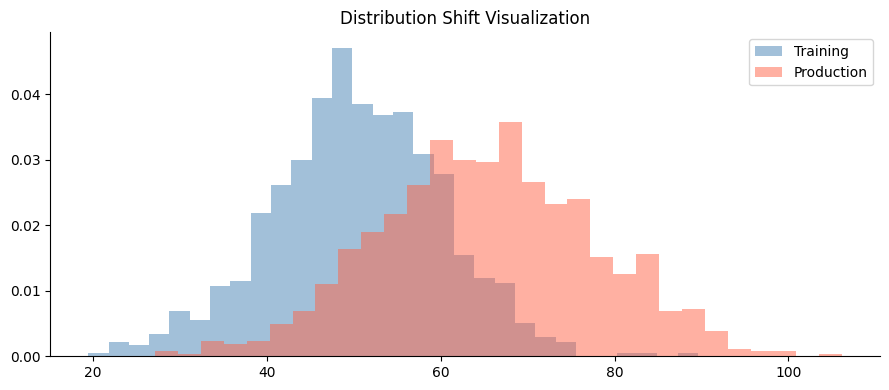

In [ ]:
def compute_psi(expected, actual, bins=10):
    """
    PSI = sum((actual_pct - expected_pct) * ln(actual_pct / expected_pct))
    Add epsilon=1e-10 to avoid log(0).
    """
    eps = 1e-10
    breakpoints = np.linspace(
        min(expected.min(), actual.min()),
        max(expected.max(), actual.max()),
        bins + 1
    )
    exp_pct = np.histogram(expected, bins=breakpoints)[0] / len(expected) + eps
    act_pct = np.histogram(actual,   bins=breakpoints)[0] / len(actual)   + eps
    return float(np.sum((act_pct - exp_pct) * np.log(act_pct / exp_pct)))

np.random.seed(1)
train_dist = np.random.normal(50, 10, 1000)    # training distribution
drift_dist = np.random.normal(65, 12, 1000)    # shifted production distribution

psi_value = compute_psi(train_dist, drift_dist)
print(f"PSI: {psi_value:.4f}")
print(f"Shift severity: {'Major' if psi_value > 0.2 else 'Minor' if psi_value > 0.1 else 'Stable'}")

# Plot both distributions
fig, ax = plt.subplots()
ax.hist(train_dist, bins=30, alpha=0.5, density=True, color='steelblue', label='Training')
ax.hist(drift_dist, bins=30, alpha=0.5, density=True, color='tomato',    label='Production')
ax.legend(); ax.set_title('Distribution Shift Visualization')
plt.tight_layout(); plt.show()

**Concept Drift vs Covariate Drift & PSI Thresholds (5.5):**

- **Concept drift:** The relationship between input features and the target variable changes over time (e.g. the pattern that predicts churn shifts because customer behaviour evolves).
- **Covariate drift:** The statistical distribution of *input features* changes, even if the underlying relationship to the target stays the same (e.g. average customer age shifts after a new product launch).
- **PSI < 0.1:** No meaningful shift — distribution is stable; no action needed.
- **PSI 0.1–0.2:** Minor shift — monitor closely and investigate the cause.
- **PSI > 0.2:** Major shift — the input distribution has changed significantly; model retraining is likely required.
- **Retraining trigger example:** Schedule an automated retraining pipeline whenever the weekly PSI on any key feature exceeds 0.2 for two consecutive monitoring windows.

---
## Part 6 — Probability Theory

### 6.1 Core Concepts

In [ ]:
total = 10
red, blue, green = 4, 3, 3

p_red   = red/total
p_blue  = blue/total
p_green = green/total

# Joint: P(red first AND blue second)
p_red_then_blue = (red/total)*(blue/(total-1))

# Conditional: P(blue second | red first)
p_blue_given_red = blue/(total-1)

# Independence check: are P(B|A) == P(B) ?
independent = math.isclose(p_blue_given_red, p_blue) if 'math' in globals() else abs(p_blue_given_red - p_blue) < 1e-9

print(f"P(red)={p_red:.3f}, P(blue)={p_blue:.3f}, P(green)={p_green:.3f}")
print(f"P(red,blue): {p_red_then_blue:.4f}")
print(f"P(blue|red): {p_blue_given_red:.4f}")
print(f"P(blue):     {p_blue:.4f}")
print(f"Independent? {independent}")

P(red)=0.400, P(blue)=0.300, P(green)=0.300
P(red,blue): 0.1333
P(blue|red): 0.3333
P(blue):     0.3000
Independent? False


### 6.2 Distributions in the Wild

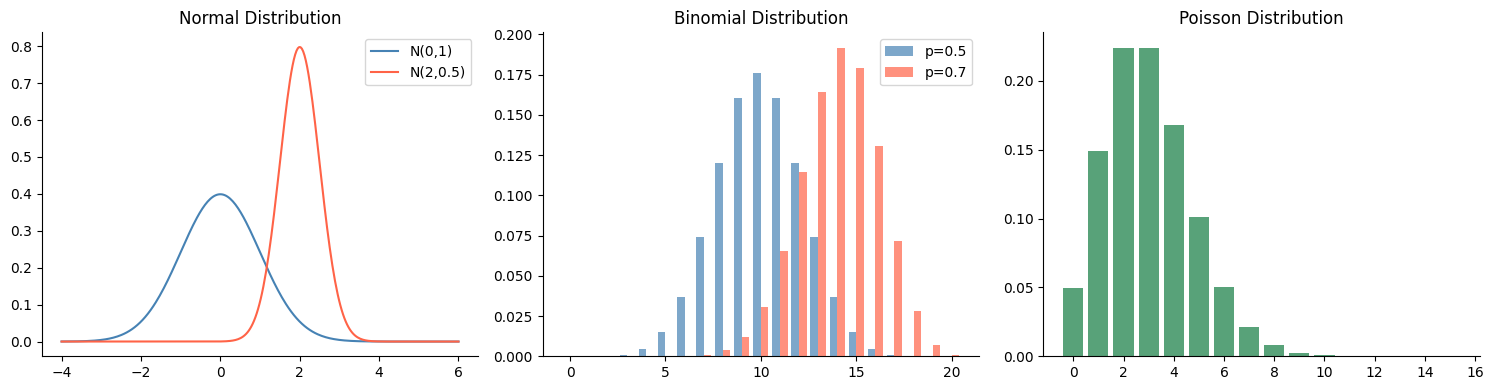

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── Normal ──────────────────────────────────────────────────────────────────
x = np.linspace(-4, 6, 300)
axes[0].plot(x, stats.norm.pdf(x, 0, 1),   label='N(0,1)',     color='steelblue')
axes[0].plot(x, stats.norm.pdf(x, 2, 0.5), label='N(2,0.5)',   color='tomato')
axes[0].legend(); axes[0].set_title('Normal Distribution')
# ML use case: modelling residuals in linear regression; weight initialisation in neural networks

# ── Binomial ────────────────────────────────────────────────────────────────
k = np.arange(0, 21)
axes[1].bar(k - 0.2, stats.binom.pmf(k, 20, 0.5), width=0.4, alpha=0.7, label='p=0.5', color='steelblue')
axes[1].bar(k + 0.2, stats.binom.pmf(k, 20, 0.7), width=0.4, alpha=0.7, label='p=0.7', color='tomato')
axes[1].legend(); axes[1].set_title('Binomial Distribution')
# ML use case: number of correct class predictions in a batch; click-through counts in A/B testing

# ── Poisson ─────────────────────────────────────────────────────────────────
k2 = np.arange(0, 16)
axes[2].bar(k2, stats.poisson.pmf(k2, mu=3), color='seagreen', alpha=0.8)
axes[2].set_title('Poisson Distribution')
# ML use case: modelling rare event counts (fraud transactions, server errors per minute)

plt.tight_layout(); plt.show()

### 6.3 Bayes' Theorem

In [ ]:
p_spam            = 0.30
p_free_given_spam = 0.80
p_free_given_ham  = 0.05
p_ham             = 1 - p_spam

# P(free) — law of total probability
p_free = p_free_given_spam * p_spam + p_free_given_ham * p_ham

# Bayes
p_spam_given_free = (p_free_given_spam * p_spam) / p_free

print(f"P('free'): {p_free:.4f}")
print(f"P(Spam | 'free'): {p_spam_given_free:.4f}")

def naive_bayes_predict(prior_spam, p_word_given_spam, p_word_given_ham):
    p_ham_local = 1 - prior_spam
    p_word = p_word_given_spam * prior_spam + p_word_given_ham * p_ham_local
    return (p_word_given_spam * prior_spam) / p_word

pred = naive_bayes_predict(0.30, 0.80, 0.05)
assert abs(pred - p_spam_given_free) < 1e-9
print(f"naive_bayes_predict: {pred:.4f}")
print("6.3 passed ✓")

P('free'): 0.2750
P(Spam | 'free'): 0.8727
naive_bayes_predict: 0.8727
6.3 passed ✓


**Bayes Term Mapping (6.3):**

| Term | Formula | In this example |
|------|---------|-----------------|
| Prior | P(Spam) | 0.30 — our initial belief that any email is spam before seeing its words |
| Likelihood | P(word \| Spam) | P("free" \| Spam) = 0.80 — how likely spam emails contain the word "free" |
| Evidence | P(word) | P("free") = 0.275 — overall probability the word "free" appears in any email |
| Posterior | P(Spam \| word) | P(Spam \| "free") ≈ 0.873 — updated belief that the email is spam after seeing "free" |

### 6.4 Central Limit Theorem

Population mean: 1.0005, Population std: 1.0006
Sample means mean: 1.0021, std: 0.1845
CLT predicted std: 0.1827


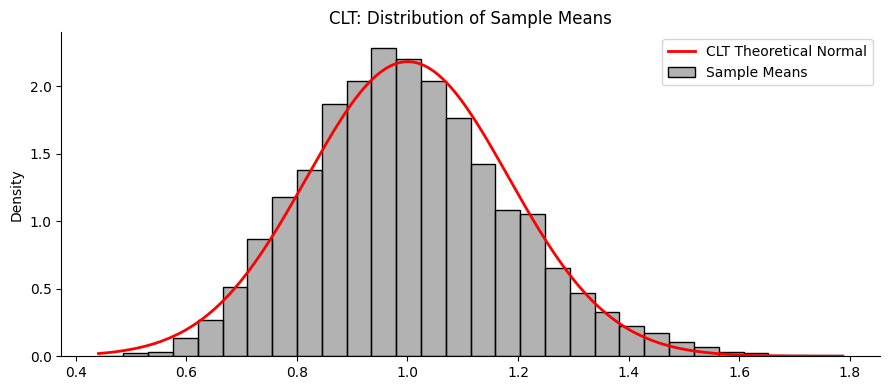

KS test p-value: 0.0054 → Approximately normal? False


In [ ]:
np.random.seed(7)
population = np.random.exponential(scale=1.0, size=100_000)

n_samples   = 5000
sample_size = 30
sample_means = np.array([
    np.random.choice(population, size=sample_size, replace=False).mean()
    for _ in range(n_samples)
])

pop_mean = population.mean()
pop_std  = population.std()
clt_std  = pop_std / np.sqrt(sample_size)   # predicted std of sample means

print(f"Population mean: {pop_mean:.4f}, Population std: {pop_std:.4f}")
print(f"Sample means mean: {sample_means.mean():.4f}, std: {sample_means.std():.4f}")
print(f"CLT predicted std: {clt_std:.4f}")

# Plot
fig, ax = plt.subplots()
sns.histplot(sample_means, kde=False, stat='density', bins=30, ax=ax, color='gray', alpha=0.6, label='Sample Means')
x_axis = np.linspace(sample_means.min(), sample_means.max(), 200)
ax.plot(x_axis, stats.norm.pdf(x_axis, pop_mean, clt_std), 'r-', lw=2, label='CLT Theoretical Normal')
ax.set_title('CLT: Distribution of Sample Means')
ax.legend()
plt.tight_layout()
plt.show()

# KS test
ks_result = stats.kstest(sample_means, 'norm', args=(pop_mean, clt_std))
print(f"KS test p-value: {ks_result.pvalue:.4f} → Approximately normal? {ks_result.pvalue > 0.05}")

**CLT Reflection (6.4):**

The CLT guarantees that no matter how skewed or strange the underlying population distribution is, the distribution of sample means will converge to a normal distribution as sample size grows — this is why so many classical tests (t-tests, z-tests, ANOVA) assume normality of the *sampling distribution* rather than the raw data. In ML it underpins the reliability of cross-validation estimates, confidence intervals for model metrics, and the assumption that averaged gradient updates in mini-batch SGD behave approximately normally, making variance-reduction techniques predictable.